# Stage 1: Short-Time Energy, Zero-Crossing Rate, and Voiced/Unvoiced/Silence Classification

This stage derives two per-frame features, Short-Time Energy (STE) and Zero-Crossing Rate (ZCR), from first principles, and uses them jointly to classify each frame of an utterance as silence, voiced speech, or unvoiced speech.

In [1]:
import numpy as np
import librosa
import matplotlib.pyplot as plt

DATA_ROOT = "../data/fluent_speech_commands_dataset"
WAV_PATH = f"{DATA_ROOT}/wavs/speakers/2BqVo8kVB2Skwgyb/ac4fca80-447a-11e9-a9a5-5dbec3b8816a.wav"
TRANSCRIPT = "Bring socks"

y, sr = librosa.load(WAV_PATH, sr=None)

FRAME_MS, HOP_MS = 25, 10
frame_len = int(sr * FRAME_MS / 1000)
hop_len = int(sr * HOP_MS / 1000)

frames = librosa.util.frame(y, frame_length=frame_len, hop_length=hop_len)
n_frames = frames.shape[1]
frame_times = (np.arange(n_frames) * hop_len + frame_len / 2) / sr

print(f"Transcript: {TRANSCRIPT!r}")
print(f"Duration: {len(y)/sr:.3f} s, {n_frames} frames")

Transcript: 'Bring socks'
Duration: 1.765 s, 174 frames


## Short-Time Energy

Short-Time Energy is defined, for a frame of samples $x[n]$, as

$$E = \sum_{n} x[n]^2$$

the sum of squared sample amplitudes within the frame. Squaring gives a measure proportional to signal power and is dominated by high-amplitude samples, so voiced segments (large vocal-tract excitation) yield high energy, silence yields near-zero energy, and unvoiced segments fall in between.

In [2]:
def short_time_energy(frames):
    return np.sum(frames.astype(np.float64) ** 2, axis=0)

ste = short_time_energy(frames)
ste_db = 10 * np.log10(ste + 1e-10)  # log scale, small epsilon avoids log(0)

## Zero-Crossing Rate

Zero-Crossing Rate is the fraction of adjacent sample pairs within a frame whose sign differs:

$$\mathrm{ZCR} = \frac{1}{N-1}\sum_{n=1}^{N-1} \tfrac{1}{2}\left|\operatorname{sign}(x[n]) - \operatorname{sign}(x[n-1])\right|$$

A high zero-crossing rate indicates that the signal changes sign rapidly, characteristic of the broadband, noise-like energy produced by unvoiced fricatives; a low rate indicates a signal dominated by low-frequency periodic energy, characteristic of voiced sounds.

In [3]:
def zero_crossing_rate(frames):
    signs = np.sign(frames)
    signs[signs == 0] = 1  # treat an exact zero sample as positive, avoids spurious crossings
    sign_changes = np.abs(np.diff(signs, axis=0)) / 2
    return np.mean(sign_changes, axis=0)

zcr = zero_crossing_rate(frames)

## Voiced / Unvoiced / Silence classification

Each frame is labeled using both features jointly: energy separates silence from speech, and zero-crossing rate then separates the speech frames into voiced and unvoiced. The energy threshold is set a fixed margin above the utterance's own noise floor (estimated as the 15th percentile of frame energies), and the zero-crossing threshold is set at the 70th percentile of zero-crossing rate among the frames already classified as speech. Both thresholds are relative to the utterance's own statistics rather than fixed absolute values, since amplitude scale varies across recordings.

In [4]:
# Energy threshold: a fixed margin above the utterance's own noise floor.
noise_floor_db = np.percentile(ste_db, 15)
energy_thresh_db = noise_floor_db + 10  # dB above floor
is_speech = ste_db > energy_thresh_db

# ZCR threshold: set only from frames already known to be speech, so silence-region
# noise (which has its own, unrelated ZCR statistics) doesn't skew the split.
zcr_thresh = np.percentile(zcr[is_speech], 70)

labels = np.full(n_frames, "S", dtype="<U1")  # default: silence
labels[is_speech & (zcr <= zcr_thresh)] = "V"   # voiced
labels[is_speech & (zcr > zcr_thresh)] = "U"    # unvoiced

label_counts = {l: int(np.sum(labels == l)) for l in "VUS"}
print(f"Noise floor: {noise_floor_db:.1f} dB, energy threshold: {energy_thresh_db:.1f} dB, ZCR threshold: {zcr_thresh:.4f}")
print(f"Frame counts -> Voiced: {label_counts['V']}, Unvoiced: {label_counts['U']}, Silence: {label_counts['S']}")

Noise floor: -63.3 dB, energy threshold: -53.3 dB, ZCR threshold: 0.0702
Frame counts -> Voiced: 75, Unvoiced: 30, Silence: 69


## Time-aligned visualization

The waveform, short-time energy, zero-crossing rate, and the resulting voiced/unvoiced/silence classification are plotted on a shared time axis below.

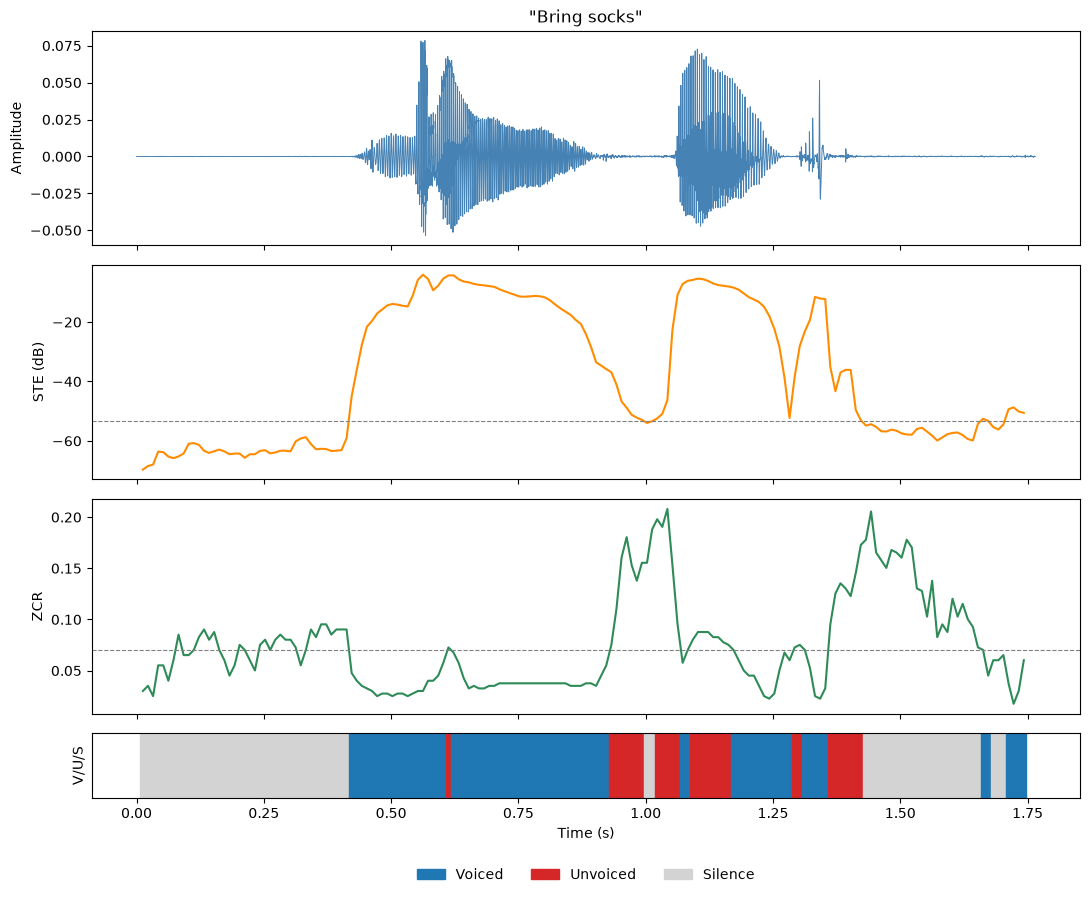

In [5]:
fig, axes = plt.subplots(4, 1, figsize=(11, 9), sharex=True,
                          gridspec_kw={"height_ratios": [2, 2, 2, 0.6]})

t = np.arange(len(y)) / sr
axes[0].plot(t, y, linewidth=0.7, color="steelblue")
axes[0].set_ylabel("Amplitude")
axes[0].set_title(f'"{TRANSCRIPT}"')

axes[1].plot(frame_times, ste_db, color="darkorange")
axes[1].axhline(energy_thresh_db, color="gray", linestyle="--", linewidth=0.8)
axes[1].set_ylabel("STE (dB)")

axes[2].plot(frame_times, zcr, color="seagreen")
axes[2].axhline(zcr_thresh, color="gray", linestyle="--", linewidth=0.8)
axes[2].set_ylabel("ZCR")

color_map = {"V": "tab:blue", "U": "tab:red", "S": "lightgray"}
for i in range(n_frames):
    left = frame_times[i] - hop_len / (2 * sr)
    axes[3].axvspan(left, left + hop_len / sr, color=color_map[labels[i]])
axes[3].set_yticks([])
axes[3].set_ylabel("V/U/S")
axes[3].set_xlabel("Time (s)")

from matplotlib.patches import Patch
legend_handles = [Patch(color=c, label=l) for l, c in zip(
    ["Voiced", "Unvoiced", "Silence"], ["tab:blue", "tab:red", "lightgray"])]
axes[3].legend(handles=legend_handles, loc="upper center", bbox_to_anchor=(0.5, -0.9),
               ncol=3, frameon=False)

fig.tight_layout()
plt.show()

## Results

Of the 174 frames in the utterance, 75 were classified as voiced, 30 as unvoiced, and 69 as silence. The resulting frame-level classification is consistent with the phonetic content of "Bring socks": an initial silence, followed by a sustained voiced region corresponding to "Bring," a region of elevated zero-crossing rate and reduced energy corresponding to the /s/ onset of "socks," a further voiced region corresponding to the vowel, a transitional region of reduced energy corresponding to the stop consonant /k/, a second elevated zero-crossing-rate region corresponding to the final /s/, and a closing silence.

The stop consonant /k/ is not cleanly classified as either voiced or unvoiced. This is consistent with its acoustic structure: a stop consists of a brief silent closure followed by a short release burst, which does not present the sustained energy or zero-crossing signature that the frame-level thresholding scheme is designed to detect, and is a known limitation of frame-based STE/ZCR classification for plosive consonants.

The energy and zero-crossing-rate thresholds were computed relative to the utterance's own statistics (15th-percentile noise floor plus a fixed margin for energy; 70th percentile of the zero-crossing rate among frames already classified as speech, for the voiced/unvoiced split), rather than fixed absolute values, since absolute signal amplitude varies with recording device and speaker across the corpus.